<div align="center">
<h1><b> Distorted Visual Sequence Pattern Recognition using Deep Learning</b></h1>
</div>

# 1. Introduction & Problem Understanding

### Problem Summary

This project addresses the challenge of recognizing text sequences from heavily distorted grayscale images. Standard OCR systems assume relatively clean input — readable fonts, consistent spacing, and minimal noise. Real-world scenarios frequently violate these assumptions. This challenge simulates exactly such conditions.

Given a grayscale image containing a hidden text sequence that has been corrupted by various types of visual distortions, the objective is to correctly predict the ordered sequence of characters present in the image.

### Evaluation Metric

- Model performance will be evaluated using **Character Error Rate (CER)**, which measures the difference between the predicted character sequence and the ground-truth sequence.

CER is based on the Levenshtein Edit Distance and is defined as:

$$ CER = \frac{S + D + I}{N}$$

where:

* **S** = Number of substitutions
* **D** = Number of deletions
* **I** = Number of insertions
* **N** = Total number of characters in the ground-truth sequence

A lower CER indicates better recognition performance.

### Chosen Approach

The solution follows a **CRNN (Convolutional Recurrent Neural Network)** pipeline trained entirely from scratch on the provided dataset:

```text
Distorted Image
      │
      ▼
 CNN Backbone          ← Extracts spatial visual features
      │
      ▼
 BiLSTM Encoder        ← Models sequential character dependencies
      │
      ▼
 Linear Projection     ← Maps to character vocabulary probabilities
      │
      ▼
 CTC Decoding          ← Produces final text sequence without alignment
      │
      ▼
 Predicted Text
```

- **CNN** handles the spatial complexity of distorted characters.
- **BiLSTM** captures the sequential structure of text (characters appear left-to-right).
- **CTC Loss** allows training without needing to know exactly where each character is located in the image — only what the full sequence is.

# 2. Environment Setup & Imports

This section handles all library imports, random seed configuration for reproducibility, and device setup. All imports for the entire notebook are consolidated here so that dependencies are immediately visible and the notebook can be verified for completeness before any heavy computation begins.

### 2.1 Library Imports

In [1]:
# Install required libraries not pre-installed on Google Colab
%pip install editdistance albumentations --quiet
print("Packages installed.")

# Mount Google Drive to access your uploaded zip file
from google.colab import drive
drive.mount('/content/drive')

# Unzip your dataset from Drive

ZIP_PATH    = "/content/drive/MyDrive/cig_ps.zip"
EXTRACT_DIR = "/content/dataset"

import zipfile, os

os.makedirs(EXTRACT_DIR, exist_ok=True)

print(f"Unzipping {ZIP_PATH} ...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)
print("Unzip complete.")

# Confirm extracted structure
for root, dirs, files in os.walk(EXTRACT_DIR):
    level = root.replace(EXTRACT_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:5]:
            print(f"{'  ' * (level+1)}{f}")
        if len(files) > 5:
            print(f"{'  ' * (level+1)}... and {len(files)-5} more files")

Packages installed.
Mounted at /content/drive
Unzipping /content/drive/MyDrive/cig_ps.zip ...
Unzip complete.
dataset/
  cig_ps/
    train-labels.csv
    train_images/
    test_images/


In [2]:
# Importing of libraries
import os
import sys
import random
import time
import math
from pathlib import Path

import numpy as np
import pandas as pd

import cv2
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
import torchvision.transforms as transforms

import albumentations as A
from albumentations.pytorch import ToTensorV2

import editdistance

from tqdm import tqdm
from sklearn.model_selection import train_test_split

print("All libraries imported successfully.")

All libraries imported successfully.


### 2.2 Reproducibility (Seed Configuration)

Deep learning experiments involve randomness at multiple levels: weight initialization, data shuffling in DataLoaders, dropout during training, and data augmentation transforms. Setting fixed seeds across all random number generators ensures that every run of this notebook produces identical results, making the work reproducible and the experiments comparable.

In [3]:
def set_seed(seed: int = 42) -> None:
    """
    Sets random seeds across all libraries and frameworks to ensure
    full reproducibility of experiments.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)


SEED = 42
set_seed(SEED)
print(f"Random seed set to: {SEED}")
print("Reproducibility configured")

Random seed set to: 42
Reproducibility configured


### 2.3 Device Configuration

PyTorch requires explicitly specifying whether computations run on the CPU or GPU. The code below automatically detects the best available device.

- If an NVIDIA GPU with CUDA is available → uses GPU (fast training)
- If on Apple Silicon Mac with MPS → uses MPS backend (moderate speed)
- Otherwise → falls back to CPU (functional for testing; use Google Colab for full training)

In [4]:
def get_device() -> torch.device:
    """
    Detects and returns the best available compute device.
    Priority: CUDA > MPS > CPU
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
        device_name = torch.cuda.get_device_name(0)
        vram = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
        print(f"Device    : CUDA (GPU)")
        print(f"GPU Name  : {device_name}")
        print(f"VRAM      : {vram:.2f} GB")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print(f"Device    : MPS (Apple Silicon GPU)")
    else:
        device = torch.device("cpu")
        print(f"Device    : CPU")
        print(f"Note      : No GPU detected. Use Google Colab for full training.")
    return device


DEVICE = get_device()
print(f"\nAll tensors and models will be moved to: {DEVICE}")

Device    : CUDA (GPU)
GPU Name  : Tesla T4
VRAM      : 14.56 GB

All tensors and models will be moved to: cuda


### 2.4 Project Configuration

All key project-level constants and path configurations are defined here in one place. This makes it easy to adjust settings without hunting through the notebook for hardcoded values.

In [5]:
DATA_ROOT      = Path("/content/dataset/cig_ps")
TRAIN_DIR      = DATA_ROOT / "train_images"
TEST_DIR       = DATA_ROOT / "test_images"
LABEL_FILE     = DATA_ROOT / "train-labels.csv"
OUTPUT_DIR     = Path("/content/outputs")
CHECKPOINT_DIR = Path("/content/checkpoints")

DRIVE_CHECKPOINT_DIR = Path("/content/drive/MyDrive/ocr_checkpoints")
DRIVE_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Image Configuration
IMG_HEIGHT   = 64     # Increased from 32 — needed to preserve detail around the occlusion
IMG_WIDTH    = 128    # Sufficient for 6-character sequences
IMG_CHANNELS = 1      # Grayscale

# Training Hyperparameters
BATCH_SIZE    = 32
NUM_EPOCHS    = 30
LEARNING_RATE = 1e-4
VAL_SPLIT     = 0.15    # 15% of training data for validation

# Model Configuration
CNN_OUTPUT_CHANNELS = 256
RNN_HIDDEN_SIZE     = 256
RNN_NUM_LAYERS      = 2
DROPOUT_RATE        = 0.3

# Print Summary

print("PROJECT CONFIGURATION SUMMARY\n")
print(f"Data Root       : {DATA_ROOT}")
print(f"Train Dir       : {TRAIN_DIR}")
print(f"Test Dir        : {TEST_DIR}")
print(f"Image Size      : {IMG_HEIGHT} x {IMG_WIDTH} (H x W)")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Epochs          : {NUM_EPOCHS}")
print(f"Learning Rate   : {LEARNING_RATE}")
print(f"Val Split       : {int(VAL_SPLIT * 100)}%")
print(f"Device          : {DEVICE}")
print(f"Output Dir      : {OUTPUT_DIR}")
print(f"Checkpoint Dir  : {CHECKPOINT_DIR}")
print("=" * 50)

PROJECT CONFIGURATION SUMMARY

Data Root       : /content/dataset/cig_ps
Train Dir       : /content/dataset/cig_ps/train_images
Test Dir        : /content/dataset/cig_ps/test_images
Image Size      : 64 x 128 (H x W)
Batch Size      : 32
Epochs          : 30
Learning Rate   : 0.0001
Val Split       : 15%
Device          : cuda
Output Dir      : /content/outputs
Checkpoint Dir  : /content/checkpoints


# 3. Dataset Loading & Exploration (EDA)

Before writing any model code, it is essential to deeply understand the dataset. This section loads the training data, visualizes sample images, and analyzes the label distribution. Observations made here directly influence preprocessing, augmentation, and model design decisions made in later sections.

### 3.1 Loading File Paths and Labels

In [6]:
# Load the label CSV
df_train = pd.read_csv(LABEL_FILE)

print("Raw CSV columns :", df_train.columns.tolist())
print("First 3 rows:")
print(df_train.head(3))

# Normalize column names

col_map = {}
for col in df_train.columns:
    col_lower = col.strip().lower()
    if col_lower in ["image"]:
        col_map[col] = "image"
    elif col_lower in ["text"]:
        col_map[col] = "label"

df_train = df_train.rename(columns=col_map)

# Confirm both required columns exist
assert "image" in df_train.columns, \
    f"Could not find image/filename column. Columns found: {df_train.columns.tolist()}"
assert "label" in df_train.columns, \
    f"Could not find label/text column. Columns found: {df_train.columns.tolist()}"

# Convert labels to string (in case they are numeric)
df_train["label"] = df_train["label"].astype(str)

# Build full image paths
df_train["image_path"] = df_train["image"].apply(
    lambda x: str(TRAIN_DIR / x)
)

# Verify images actually exist on disk and drop any broken rows
exists_mask  = df_train["image_path"].apply(lambda p: os.path.isfile(p))
missing      = (~exists_mask).sum()
if missing > 0:
    print(f"WARNING: {missing} image files not found on disk — dropping them.")
    df_train = df_train[exists_mask].reset_index(drop=True)

# Load test image paths
test_images = sorted(
    list(TEST_DIR.glob("*.png")) +
    list(TEST_DIR.glob("*.jpg")) +
    list(TEST_DIR.glob("*.jpeg"))
)
df_test = pd.DataFrame({
    "image"      : [p.name for p in test_images],
    "image_path" : [str(p) for p in test_images]
})

print(f"\nTraining samples  : {len(df_train)}")
print(f"Test samples      : {len(df_test)}")
print(f"\nSample training rows:")
print(df_train[["image", "label"]].head())

Raw CSV columns : ['Unnamed: 0', 'image', 'text']
First 3 rows:
   Unnamed: 0        image    text
0           0  train-0.png  BU522X
1           1  train-1.png  XQ8NE2
2           2  train-2.png  DTZD3E

Training samples  : 20000
Test samples      : 5000

Sample training rows:
         image   label
0  train-0.png  BU522X
1  train-1.png  XQ8NE2
2  train-2.png  DTZD3E
3  train-3.png  SM424H
4  train-4.png  6YVTQR


### 3.2 Dataset Statistics

Understanding image dimensions is critical. If images vary in size, we must decide on a fixed resize target. If they are already uniform, we can confirm our configuration matches.

IMAGE DIMENSION STATISTICS (sampled from training set)
Height — Min: 100, Max: 100, Mean: 100.0
Width  — Min: 200,  Max: 200,  Mean: 200.0

Configured resize target : 64 x 128 (H x W)


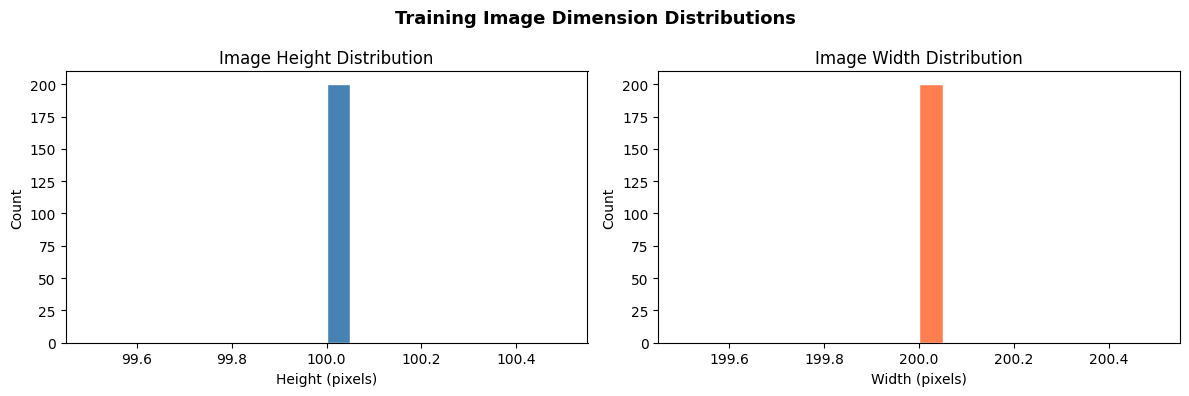

In [7]:
# Read a sample of images to check dimensions
sample_size = min(200, len(df_train))
heights, widths = [], []

for path in df_train["image_path"].sample(sample_size, random_state=SEED):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        heights.append(img.shape[0])
        widths.append(img.shape[1])

print("IMAGE DIMENSION STATISTICS (sampled from training set)")
print("=" * 50)
print(f"Height — Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.1f}")
print(f"Width  — Min: {min(widths)},  Max: {max(widths)},  Mean: {np.mean(widths):.1f}")
print(f"\nConfigured resize target : {IMG_HEIGHT} x {IMG_WIDTH} (H x W)")

# Plot dimension distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(heights, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title("Image Height Distribution")
axes[0].set_xlabel("Height (pixels)")
axes[0].set_ylabel("Count")
axes[1].hist(widths, bins=20, color='coral', edgecolor='white')
axes[1].set_title("Image Width Distribution")
axes[1].set_xlabel("Width (pixels)")
axes[1].set_ylabel("Count")
plt.suptitle("Training Image Dimension Distributions", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "eda_image_dimensions.png"), dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Sample Image Visualization

Visually examining samples from the training set is essential before building any pipeline. This allows us to confirm the data loaded correctly and observe the types and severity of distortions present.

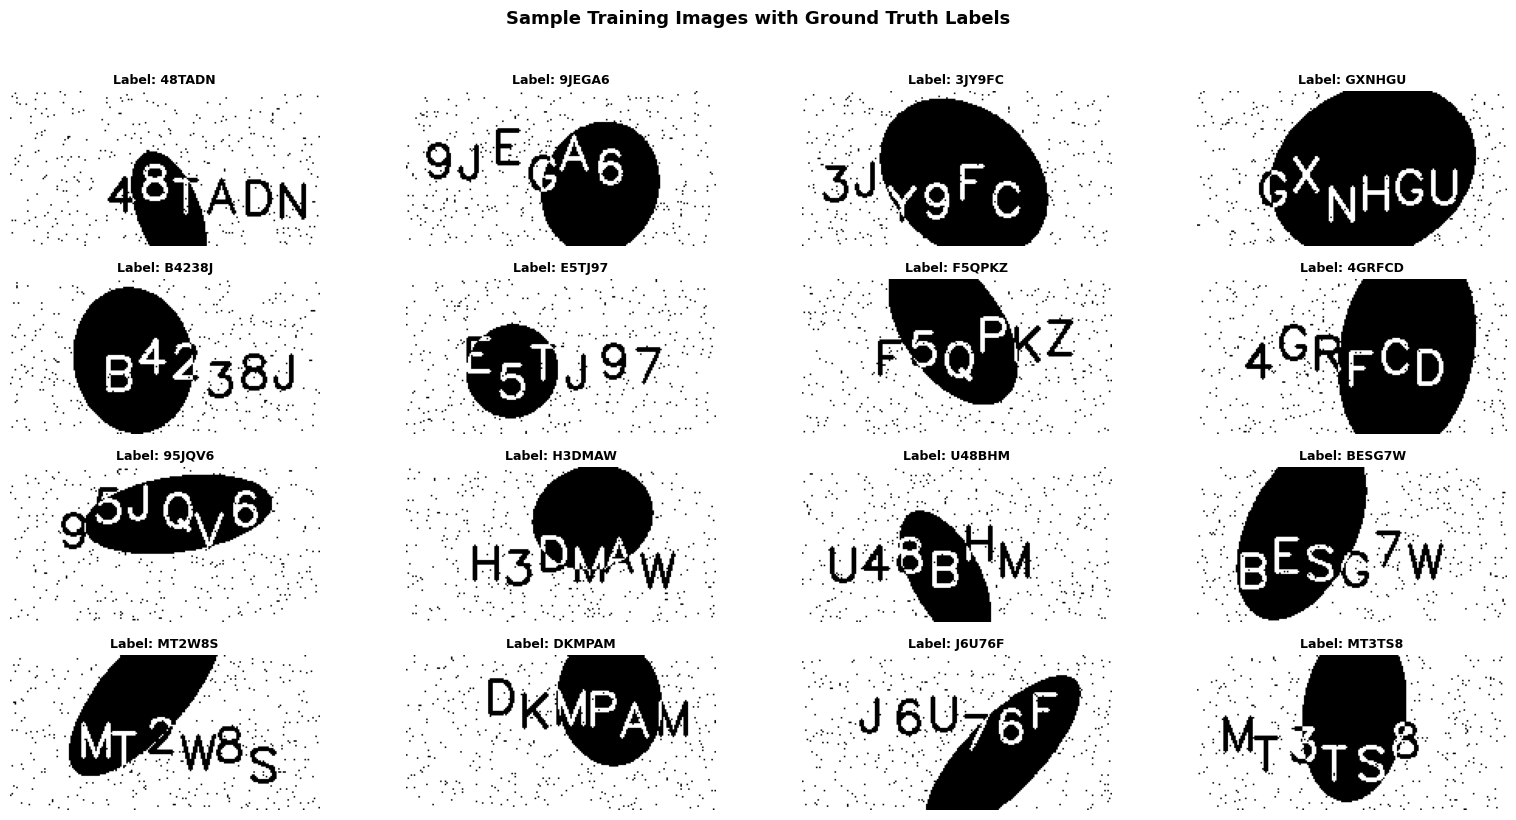

In [8]:
# Display a grid of 16 random training images with their labels
sample_df = df_train.sample(16, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(4, 4, figsize=(16, 8))
axes = axes.flatten()

for i, row in sample_df.iterrows():
    img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
    if img is not None:
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(f'Label: {row["label"]}', fontsize=9, fontweight='bold')
    axes[i].axis("off")

plt.suptitle("Sample Training Images with Ground Truth Labels", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "eda_sample_images.png"), dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Label Analysis

Analyzing the labels helps us determine the vocabulary size (which defines the model output dimension), the range of sequence lengths (which informs model capacity), and character frequency (which may reveal class imbalance).

LABEL STATISTICS

Min length  : 6
Max length  : 9
Mean length : 6.00
Std dev     : 0.03

Vocabulary size : 38
Characters      : +-.0123456789ABCDEFGHJKMNPQRSTUVWXYZar


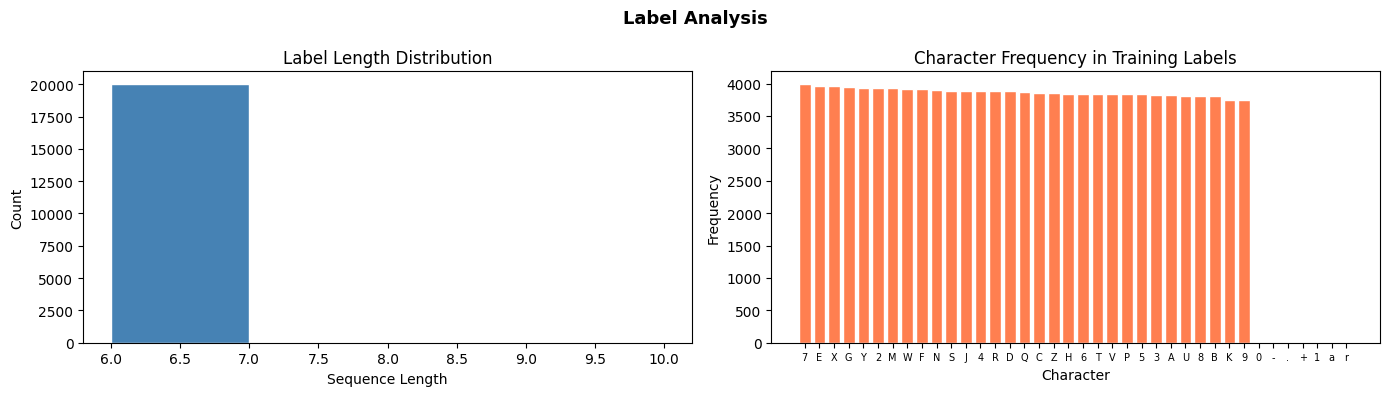

In [9]:
# Label length analysis
df_train["label_len"] = df_train["label"].apply(len)

print("LABEL STATISTICS\n")
print(f"Min length  : {df_train['label_len'].min()}")
print(f"Max length  : {df_train['label_len'].max()}")
print(f"Mean length : {df_train['label_len'].mean():.2f}")
print(f"Std dev     : {df_train['label_len'].std():.2f}")

# All unique characters across all labels
all_chars = sorted(set("".join(df_train["label"].tolist())))
print(f"\nVocabulary size : {len(all_chars)}")
print(f"Characters      : {''.join(all_chars)}")

# Character frequency
char_counts = {}
for label in df_train["label"]:
    for ch in label:
        char_counts[ch] = char_counts.get(ch, 0) + 1
char_counts = dict(sorted(char_counts.items(), key=lambda x: -x[1]))

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Label length distribution
axes[0].hist(df_train["label_len"], bins=range(df_train["label_len"].min(),
             df_train["label_len"].max() + 2), color='steelblue', edgecolor='white')
axes[0].set_title("Label Length Distribution")
axes[0].set_xlabel("Sequence Length")
axes[0].set_ylabel("Count")

# Character frequency bar chart
axes[1].bar(char_counts.keys(), char_counts.values(), color='coral', edgecolor='white')
axes[1].set_title("Character Frequency in Training Labels")
axes[1].set_xlabel("Character")
axes[1].set_ylabel("Frequency")
axes[1].tick_params(axis='x', labelsize=7)

plt.suptitle("Label Analysis", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "eda_label_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Distortion Observations

**Primary Distortion — Large Black Elliptical Blob (Severe)**
Every image contains a single large solid black oval or elliptical
shape that is placed roughly in the center of the image. This blob:
- Covers approximately 30–50% of the total image area
- Completely occludes whatever characters lie beneath it
- Forces the model to infer hidden characters from surrounding context
- Is the single most challenging aspect of this dataset

**Secondary Distortions (Mild)**
- Light salt-and-pepper noise across the background
- Slight graininess in the image texture
- Minor variations in character size and positioning

# 4.— Vocabulary & Label Encoding

Before any data can be fed to the model, we must convert the character labels (strings) into numerical indices the model can work with. This section builds a fixed vocabulary and implements encoding and decoding functions. The vocabulary is built from the training set and must remain fixed throughout — training, validation, and inference all use the same mappings.

### 4.1 Character Vocabulary Construction

The CTC loss function requires a blank token at index 0. This blank is used internally by CTC to separate repeated characters and represents "no character" at a given time step.

In [10]:
# Collect all unique characters from training labels
all_chars = sorted(set("".join(df_train["label"].tolist())))

# CTC blank token must be at index 0
BLANK_TOKEN = "-"
VOCAB = [BLANK_TOKEN] + all_chars

VOCAB_SIZE = len(VOCAB)
BLANK_IDX  = 0

print(f"Blank token     : '{BLANK_TOKEN}' at index {BLANK_IDX}")
print(f"Characters      : {''.join(all_chars)}")
print(f"Total vocab size: {VOCAB_SIZE} (including blank)")

Blank token     : '-' at index 0
Characters      : +-.0123456789ABCDEFGHJKMNPQRSTUVWXYZar
Total vocab size: 39 (including blank)


### 4.2 Character to Index and Index to Character Mappings

In [11]:
# char to index
char2idx = {char: idx for idx, char in enumerate(VOCAB)}

# index to char
idx2char = {idx: char for idx, char in enumerate(VOCAB)}

print("char2idx (first 5 entries):")
for k, v in list(char2idx.items())[:5]:
    print(f"  '{k}' → {v}")

print("\nidx2char (first 5 entries):")
for k, v in list(idx2char.items())[:5]:
    print(f"  {k} → '{v}'")

char2idx (first 5 entries):
  '-' → 2
  '+' → 1
  '.' → 3
  '0' → 4
  '1' → 5

idx2char (first 5 entries):
  0 → '-'
  1 → '+'
  2 → '-'
  3 → '.'
  4 → '0'


### 4.3 Label Encoding and Decoding Functions

- **Encoding**: converts a string like `AXU323` into a list of integer indices.
- **Decoding (CTC)**: converts raw CTC output indices back to a string by collapsing repeated characters and removing blank tokens.

In [12]:
def encode_label(text: str) -> list:
    """
    Converts a text string into a list of integer indices.
    """
    return [char2idx[ch] for ch in text if ch in char2idx]


def decode_ctc(indices: list) -> str:
    """
    Decodes a list of CTC output indices into a text string.
    Steps:
      1. Collapse consecutive repeated indices (CTC allows many-to-one mapping)
      2. Remove all blank token indices
      3. Map remaining indices to characters
    """
    # Collapse repeated indices
    collapsed = []
    prev = None
    for idx in indices:
        if idx != prev:
            collapsed.append(idx)
        prev = idx

    # Remove blanks and map to characters
    result = "".join([idx2char[idx] for idx in collapsed if idx != BLANK_IDX])
    return result

### 4.4 Verification Test

We verify that encoding followed by decoding returns the original string exactly, and that the CTC decoder correctly handles repeated characters and blanks.

In [13]:
# Test encoding
sample_label = df_train["label"].iloc[0]
encoded = encode_label(sample_label)
print(f"Original label   : '{sample_label}'")
print(f"Encoded indices  : {encoded}")

# Test decoding — decode back from clean indices (no CTC noise)
decoded = "".join([idx2char[i] for i in encoded])
print(f"Decoded back     : '{decoded}'")
print(f"Match            : {sample_label == decoded}")

# Test CTC decoder with simulated repeated indices and blanks
# Simulates CTC output: A A - X X X U 3 3 - 2 3 (should decode to AXSU323 → AXU323)
test_ctc = encode_label(sample_label)

# Manually insert blanks and repeats to simulate CTC behavior
simulated = []
for idx in test_ctc:
    simulated.extend([idx, idx, BLANK_IDX])

ctc_decoded = decode_ctc(simulated)
print(f"\nCTC simulated decode : '{ctc_decoded}'")
print(f"Matches original     : {ctc_decoded == sample_label}")

Original label   : 'BU522X'
Encoded indices  : [15, 31, 9, 6, 6, 34]
Decoded back     : 'BU522X'
Match            : True

CTC simulated decode : 'BU522X'
Matches original     : True


# 5. Preprocessing Pipeline

Raw images must be standardized before training. This section builds the deterministic preprocessing pipeline applied to every image regardless of whether it is in the training, validation, or test set. The key steps are resizing, normalization, and tensor conversion.

### 5.1 Resize Strategy

- Based on visual inspection of training samples, the images appear to
have a landscape orientation.
- The characters are relatively large and spaced around a central blob.

Resize target chosen: **Height = 64, Width = 128**

Reasoning:
- Height of 32 (original assumption) is too small — at 32px height,
  the large blob and surrounding characters lose too much structural
  detail. 64px preserves character edges better.
- Width of 128 is retained — sufficient for 6-character sequences
  with the blob present.
- The large black blob at 64x128 still clearly occupies a large
  fraction of the image, which is what the model needs to see.

### 5.2 — Image Loading Function

In [14]:
def load_image(image_path: str) -> np.ndarray:
    """
    Loads a grayscale image from disk.
    """
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    return img


# Test the loader on the first training image
test_img = load_image(df_train["image_path"].iloc[0])
print(f"Loaded image shape : {test_img.shape} (H x W)")
print(f"Pixel value range  : [{test_img.min()}, {test_img.max()}]")
print(f"Data type          : {test_img.dtype}")

Loaded image shape : (100, 200) (H x W)
Pixel value range  : [0, 240]
Data type          : uint8


### 5.3 Preprocessing Pipeline Composition

The base transform (applied to all splits — train, val, test) includes:
1. Resize to fixed (H, W)
2. Normalize pixel values to [0, 1] range
3. Convert to PyTorch tensor with shape (C, H, W)

In [15]:
# Base preprocessing — applied to ALL splits (train, val, test)
base_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.Normalize(mean=(0.5,), std=(0.5,)),   # Normalizes to [-1, 1]
    ToTensorV2(),                            # Converts (H, W, C) → (C, H, W)
])


def preprocess_image(image_path: str,
                     transform: A.Compose = base_transform) -> torch.Tensor:
    """
    Loads and preprocesses a single image.
    """
    img = load_image(image_path)
    # Albumentations expects (H, W, C) for grayscale with C=1
    img = np.expand_dims(img, axis=-1)   # (H, W) → (H, W, 1)
    transformed = transform(image=img)
    return transformed["image"]          # Returns (1, H, W) tensor


# Test the pipeline

sample_tensor = preprocess_image(df_train["image_path"].iloc[0])
print(f"Output tensor shape : {sample_tensor.shape}")
print(f"Output dtype        : {sample_tensor.dtype}")
print(f"Value range         : [{sample_tensor.min():.3f}, {sample_tensor.max():.3f}]")

Output tensor shape : torch.Size([1, 64, 128])
Output dtype        : torch.float32
Value range         : [-1.000, 0.882]


### 5.4 Visual Verification of Preprocessing

We show a side-by-side comparison of a raw image and its preprocessed version to confirm the pipeline is working correctly.

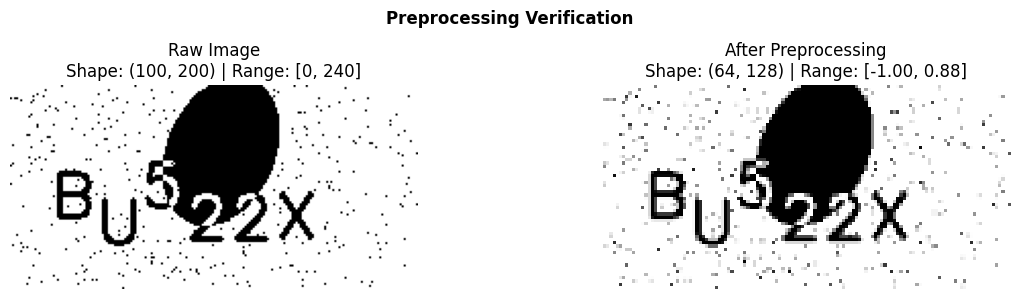

In [16]:
sample_path = df_train["image_path"].iloc[0]
raw_img     = load_image(sample_path)
proc_tensor = preprocess_image(sample_path)
proc_img    = proc_tensor.squeeze().numpy()   # (1, H, W) → (H, W)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].imshow(raw_img, cmap="gray")
axes[0].set_title(f"Raw Image\nShape: {raw_img.shape} | Range: [{raw_img.min()}, {raw_img.max()}]")
axes[0].axis("off")

axes[1].imshow(proc_img, cmap="gray")
axes[1].set_title(f"After Preprocessing\nShape: {proc_img.shape} | Range: [{proc_img.min():.2f}, {proc_img.max():.2f}]")
axes[1].axis("off")

plt.suptitle("Preprocessing Verification", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "preprocessing_verification.png"), dpi=150, bbox_inches='tight')
plt.show()

# 6. Data Augmentation

Data augmentation artificially increases the diversity of the training set by applying random transformations to images during training. This improves the model's robustness to unseen distortions and reduces overfitting. **Augmentation is only applied to training data — never to validation or test data.**

### 6.1 Augmentation Strategy

The dominant distortion observed in the actual training samples is a
large solid black elliptical blob placed roughly in the center of every
image, covering 30–50% of the image area. This is the single most
important distortion to simulate during training.

| Augmentation | Reason | Probability |
|---|---|---|
| LargeBlobOcclusion (custom) | Directly simulates the primary elliptical blob distortion observed in every training image | 0.7 |
| GaussNoise | Simulates the mild background graininess visible in training samples | 0.4 |
| RandomBrightnessContrast | Handles minor lighting and contrast variation across images | 0.3 |
| GaussianBlur | Adds mild blur to improve robustness to focus variation | 0.2 |
| GridDistortion | Simulates very mild spatial warping | 0.15 |

**Why a custom augmentation is necessary:**
No standard Albumentations transform generates a single large filled
ellipse. A custom transform class inheriting from
`ImageOnlyTransform` is built specifically for this dataset to
accurately simulate what the model will encounter at test time.

In [17]:
# Training augmentation pipeline — applied ONLY during training

train_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                                contrast_limit=0.2, p=0.4),
    A.CoarseDropout(max_holes=4, max_height=8,
                    max_width=8, fill_value=0, p=0.3),
    A.ElasticTransform(alpha=0.5, sigma=10,
                       alpha_affine=5, p=0.2),
    A.GridDistortion(num_steps=5, distort_limit=0.2, p=0.2),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# Validation / Test transform — NO augmentation, only preprocessing
val_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

print("Training augmentation pipeline created.")
print(f"Number of training transforms : {len(train_transform.transforms)}")
print("Validation/Test transform created (resize + normalize only).")

Training augmentation pipeline created.
Number of training transforms : 9
Validation/Test transform created (resize + normalize only).


/tmp/ipykernel_1209/1454264899.py:5: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10.0, 50.0), p=0.5),
/tmp/ipykernel_1209/1454264899.py:9: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=8,
/tmp/ipykernel_1209/1454264899.py:11: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=0.5, sigma=10,


### 6.2 Visual Demonstration of Augmentations

We apply the training augmentation pipeline to a single image 8 times to visualize the diversity of transformations produced.

/tmp/ipykernel_1209/2948967736.py:19: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)
/tmp/ipykernel_1209/2948967736.py:74: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),              # was p=0.4


LargeBlobOcclusion custom augmentation class defined.
Training pipeline transforms   : 7
Validation/Test pipeline       : resize + normalize only


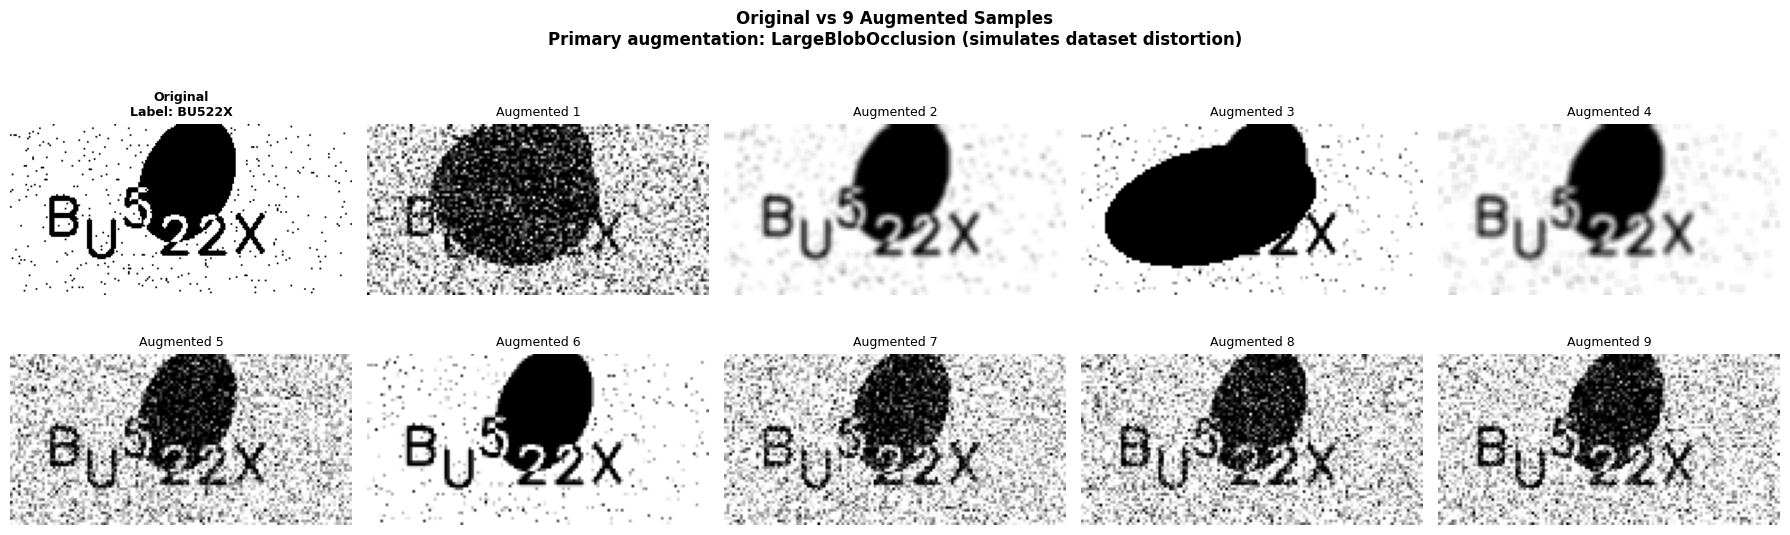

In [18]:
import random as pyrandom
import math
import cv2
import numpy as np
from albumentations.core.transforms_interface import ImageOnlyTransform

class LargeBlobOcclusion(ImageOnlyTransform):
    """
    Custom Albumentations augmentation that places a single large
    solid black elliptical blob on the image.
    This directly simulates the primary distortion observed in the
    training dataset.
    """

    def __init__(self,
                 coverage_range: tuple = (0.25, 0.55),
                 always_apply: bool = False,
                 p: float = 0.7):
        super().__init__(always_apply=always_apply, p=p)
        self.coverage_range = coverage_range

    def apply(self, img: np.ndarray, **params) -> np.ndarray:
        """
        Draws a filled black ellipse on the image.
        """
        img = img.copy()
        h, w = img.shape[:2]

        # Randomly sample how much area the blob should cover
        coverage = pyrandom.uniform(*self.coverage_range)

        # Compute ellipse semi-axes from target area
        # Ellipse area = pi * a * b  →  a * b = coverage * h * w / pi
        ab = (coverage * h * w) / math.pi

        # Aspect ratio: wider than tall to match dataset observations
        aspect = pyrandom.uniform(1.2, 2.0)

        b = max(5, int(math.sqrt(ab / aspect)))   # Semi-minor axis (vertical)
        a = max(5, int(aspect * b))               # Semi-major axis (horizontal)

        # Center: near middle of image with small random offset
        cx = int(w / 2 + pyrandom.uniform(-w * 0.15, w * 0.15))
        cy = int(h / 2 + pyrandom.uniform(-h * 0.15, h * 0.15))

        # Slight random rotation of the ellipse
        angle = pyrandom.uniform(-15, 15)

        # Draw filled solid black ellipse
        cv2.ellipse(
            img,
            center=(cx, cy),
            axes=(a, b),
            angle=angle,
            startAngle=0,
            endAngle=360,
            color=(0,) * img.shape[2],    # Black in all channels
            thickness=-1                   # -1 means filled
        )

        return img

    def get_transform_init_args_dict(self):
        return {"coverage_range": self.coverage_range}


# Training augmentation pipeline
# Applied ONLY to training data. Includes the custom blob simulation
# plus mild secondary distortions matching the dataset observations.

train_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    LargeBlobOcclusion(coverage_range=(0.20, 0.40), p=0.5),  # was p=0.7, (0.25,0.55)
    A.GaussNoise(var_limit=(5.0, 20.0), p=0.3),              # was p=0.4
    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.2                                                  # was p=0.3
    ),
    A.GaussianBlur(blur_limit=(3, 3), p=0.15),               # was p=0.2
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# Validation / Test transform
# NO augmentation — only resize and normalize..

val_transform = A.Compose([
    A.Resize(height=IMG_HEIGHT, width=IMG_WIDTH),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# Verification
print("LargeBlobOcclusion custom augmentation class defined.")
print(f"Training pipeline transforms   : {len(train_transform.transforms)}")
print("Validation/Test pipeline       : resize + normalize only")

# Visual demonstration — apply augmentation 9 times to one real image
sample_path  = df_train["image_path"].iloc[0]
raw_img      = load_image(sample_path)
raw_expanded = np.expand_dims(raw_img, axis=-1)   # (H, W) → (H, W, 1)

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

# Slot 0 — original image for comparison
axes[0].imshow(raw_img, cmap="gray")
axes[0].set_title(
    f"Original\nLabel: {df_train['label'].iloc[0]}",
    fontsize=9, fontweight='bold'
)
axes[0].axis("off")

# Slots 1–9 — augmented versions
for i in range(1, 10):
    aug     = train_transform(image=raw_expanded)["image"]
    aug_img = aug.squeeze().numpy()
    axes[i].imshow(aug_img, cmap="gray")
    axes[i].set_title(f"Augmented {i}", fontsize=9)
    axes[i].axis("off")

plt.suptitle(
    "Original vs 9 Augmented Samples\n"
    "Primary augmentation: LargeBlobOcclusion (simulates dataset distortion)",
    fontsize=12,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    str(OUTPUT_DIR / "augmentation_demo.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# 7. Dataset Class & DataLoaders

This section defines the PyTorch `Dataset` class that wraps our data, and creates `DataLoader` objects for training and validation. The DataLoader handles batching, shuffling, and parallel data loading automatically.

### 7.1 — Custom Dataset Class

In [19]:
class OCRDataset(Dataset):
    """
    Custom PyTorch Dataset for the distorted sequence recognition task.
    """

    def __init__(self, df: pd.DataFrame,
                 transform: A.Compose = None,
                 is_test: bool = False):
        self.df        = df.reset_index(drop=True)
        self.transform = transform
        self.is_test   = is_test

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img = load_image(row["image_path"])
        img = np.expand_dims(img, axis=-1)    # (H, W) → (H, W, 1)

        if self.transform:
            img = self.transform(image=img)["image"]   # → (1, H, W) tensor
        else:
            img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0

        if self.is_test:
            return img, row["image"]    # Return image and filename for test set

        label_str     = str(row["label"])
        label_encoded = torch.tensor(encode_label(label_str), dtype=torch.long)
        label_length  = torch.tensor(len(label_encoded), dtype=torch.long)

        return img, label_encoded, label_length, label_str


print("OCRDataset class defined.")

OCRDataset class defined.


### 7.2 Collate Function

Since labels have variable lengths (different sequences have different numbers of characters), PyTorch's default collate function cannot stack them into a single tensor. A custom collate function handles this by padding labels and tracking their actual lengths — information required by CTC loss.

In [20]:
def collate_fn(batch):
    """
    Custom collate function for variable-length labels.

    CTC loss requires:
      - images      : stacked tensor (B, C, H, W)
      - targets     : flat concatenated label tensor (sum of all label lengths)
      - input_lens  : length of model output sequence per sample
      - target_lens : actual label length per sample
    """
    images, labels, label_lengths, label_strs = zip(*batch)

    images = torch.stack(images, dim=0)
    targets = torch.cat(labels, dim=0)
    target_lengths = torch.stack(label_lengths, dim=0)

    return images, targets, target_lengths, list(label_strs)


print("Custom collate function defined.")

Custom collate function defined.


### 7.3 Train/Validation Split and DataLoader Construction

In [21]:
# Colab-safe multiprocessing setting
import multiprocessing
multiprocessing.set_start_method('fork', force=True)

# Split training data into train and validation subsets
train_df, val_df = train_test_split(
    df_train,
    test_size=VAL_SPLIT,
    random_state=SEED,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Training samples   : {len(train_df)}")
print(f"Validation samples : {len(val_df)}")

# Instantiate datasets
train_dataset = OCRDataset(train_df, transform=train_transform, is_test=False)
val_dataset   = OCRDataset(val_df,   transform=val_transform,   is_test=False)
test_dataset  = OCRDataset(df_test,  transform=val_transform,   is_test=True)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    persistent_workers=True
)
print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Training samples   : 17000
Validation samples : 3000

Train batches : 532
Val batches   : 94
Test batches  : 157


### 7.4 Batch Shape Verification

We load one batch from the training DataLoader and print all tensor shapes to confirm everything is wired correctly before training.

In [22]:
images, targets, target_lengths, label_strs = next(iter(train_loader))

print("BATCH VERIFICATION\n")

print(f"Images tensor shape    : {images.shape}")
print(f"\t(Batch, Channels, Height, Width)")

print(f"Targets tensor shape   : {targets.shape}")
print(f"\t(Total chars across batch — flat)")

print(f"Target lengths shape   : {target_lengths.shape}")
print(f"\tne length per sample in batch")

print(f"Sample labels          : {label_strs[:4]}")
print(f"Corresponding lengths  : {target_lengths[:4].tolist()}")
print(f"Image value range      : [{images.min():.3f}, {images.max():.3f}]")

BATCH VERIFICATION

Images tensor shape    : torch.Size([32, 1, 64, 128])
	(Batch, Channels, Height, Width)
Targets tensor shape   : torch.Size([192])
	(Total chars across batch — flat)
Target lengths shape   : torch.Size([32])
	ne length per sample in batch
Sample labels          : ['5K945B', 'NXEXTM', 'XX3CYY', 'UGPT53']
Corresponding lengths  : [6, 6, 6, 6]
Image value range      : [-1.000, 1.000]


# 8. Model Architecture

The model follows a **CRNN** (Convolutional Recurrent Neural Network) architecture built entirely from scratch. It consists of three stages:

1. **CNN Backbone** — Extracts spatial visual features from the image
2. **BiLSTM Encoder** — Models sequential dependencies across the width dimension
3. **Linear Projection** — Maps to character probability distributions

```text
Input (1, 32, 128)
    → CNN Backbone → (256, 1, 32)    [B, C, H, W]
    → Squeeze H   → (256, 32)        [B, C, W] → reshape to (32, B, 256) for RNN
    → BiLSTM      → (32, B, 512)     [T, B, 2*hidden]
    → Linear      → (32, B, vocab)   [T, B, vocab_size]
    → CTC Decode  → predicted text
```

### 8.1 CNN Backbone
Architecture:
1. 4 convolutional blocks, each consisting of:
    Conv2d → BatchNorm → ReLU → (optional MaxPool)

2. The MaxPool layers progressively reduce the height dimension:
    Input H=32 → after block1: 16 → block2: 8 → block3: 4 → block4: 1

The width dimension is preserved, forming the time/sequence axis
that will be fed into the BiLSTM.

In [23]:
class CNNBackbone(nn.Module):
    """
    Convolutional feature extractor for the CRNN model.
    Input  : (B, 1,   32, 128)
    Output : (B, 256,  1,  32)
    """

    def __init__(self):
        super(CNNBackbone, self).__init__()

        # Block 1: 1 → 64 channels | H: 32 → 16
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   # H: 32 → 16
        )

        # Block 2: 64 → 128 channels | H: 16 → 8
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)   # H: 16 → 8
        )

        # Block 3: 128 → 256 channels | H: 8 → 4
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1))  # Only pool height
        )

        # Block 4: 256 → 256 channels | H: 4 → 1
        self.block4 = nn.Sequential(
            nn.Conv2d(256, CNN_OUTPUT_CHANNELS, kernel_size=3, padding=1),
            nn.BatchNorm2d(CNN_OUTPUT_CHANNELS),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, None))   # Collapse height to exactly 1
        )

    def forward(self, x):
        # x: (B, 1, 32, 128)
        x = self.block1(x)   # (B, 64,  16, 128)
        x = self.block2(x)   # (B, 128,  8, 128)
        x = self.block3(x)   # (B, 256,  4, 128)
        x = self.block4(x)   # (B, 256,  1, W)
        return x


print("CNNBackbone class defined.")

CNNBackbone class defined.


### 8.2 Full CRNN Model

- The CNN extracts a feature map, the height dimension is squeezed to 1,
  giving a sequence of feature vectors along the width.

- This sequence is fed into a Bidirectional LSTM which models left-to-right and right-to-left context simultaneously.

- The final linear layer projects each time step to a probability distribution over the character vocabulary.


In [24]:
class CRNN(nn.Module):
    """
    Full CRNN model: CNN Backbone + BiLSTM + Linear Projection.
    Args:
        vocab_size  (int): Number of output classes including CTC blank.
        rnn_hidden  (int): Hidden units per direction in the BiLSTM.
        rnn_layers  (int): Number of stacked BiLSTM layers.
        dropout     (float): Dropout probability between RNN layers.
    """

    def __init__(self,
                 vocab_size: int  = VOCAB_SIZE,
                 rnn_hidden: int  = RNN_HIDDEN_SIZE,
                 rnn_layers: int  = RNN_NUM_LAYERS,
                 dropout: float   = DROPOUT_RATE):
        super(CRNN, self).__init__()

        self.cnn = CNNBackbone()

        # BiLSTM: input_size = CNN_OUTPUT_CHANNELS (256)
        # bidirectional=True means output size = 2 * rnn_hidden
        self.rnn = nn.LSTM(
            input_size=CNN_OUTPUT_CHANNELS,
            hidden_size=rnn_hidden,
            num_layers=rnn_layers,
            bidirectional=True,
            dropout=dropout if rnn_layers > 1 else 0.0,
            batch_first=False    # Expects (T, B, features) format
        )

        # Dropout for regularization before the final projection
        self.dropout = nn.Dropout(p=dropout)

        # Linear projection: 2*rnn_hidden → vocab_size
        self.fc = nn.Linear(rnn_hidden * 2, vocab_size)

    def forward(self, x):
        """
        Forward pass through the full CRNN pipeline.
        """

        # 1. CNN feature extraction
        x = self.cnn(x)                          # (B, 256, 1, W)

        # 2. Reshape for RNN input
        B, C, H, W = x.shape
        x = x.squeeze(2)                         # (B, 256, W) — remove H=1
        x = x.permute(2, 0, 1)                   # (W, B, 256) = (T, B, features)

        # 3. BiLSTM sequence modeling
        x, _ = self.rnn(x)                       # (T, B, 2*rnn_hidden)

        # 4. Dropout + Linear projection
        x = self.dropout(x)
        x = self.fc(x)                           # (T, B, vocab_size)

        # 5. Log-softmax — required by CTC loss
        x = F.log_softmax(x, dim=2)              # (T, B, vocab_size)

        return x


print("CRNN model class defined.")

CRNN model class defined.


### 8.3 Model Instantiation, Summary & Parameter Count

In [25]:
# Instantiate model and move to device
model = CRNN(
    vocab_size=VOCAB_SIZE,
    rnn_hidden=RNN_HIDDEN_SIZE,
    rnn_layers=RNN_NUM_LAYERS,
    dropout=DROPOUT_RATE
).to(DEVICE)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)


print("MODEL SUMMARY\n")

print(model)
print("=" * 50)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Model on device      : {DEVICE}")

MODEL SUMMARY

CRNN(
  (cnn): CNNBackbone(
    (block1): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
 

### 8.4 Forward Pass Verification

We pass a dummy input through the model to verify output shapes are correct before any training begins.

In [26]:
# Dummy input: batch of 4 grayscale images of size (32, 128)
dummy_input = torch.randn(4, 1, IMG_HEIGHT, IMG_WIDTH).to(DEVICE)

model.eval()
with torch.no_grad():
    dummy_output = model(dummy_input)

T, B, V = dummy_output.shape
print("FORWARD PASS VERIFICATION\n")

print(f"Input shape   : {dummy_input.shape}  → (B, C, H, W)")
print(f"Output shape  : {dummy_output.shape} → (T, B, vocab_size)")
print(f"  T (time steps / sequence length) : {T}")
print(f"  B (batch size)                   : {B}")
print(f"  V (vocabulary size)              : {V}")
print(f"Expected vocab size : {VOCAB_SIZE}")
print(f"Match               : {V == VOCAB_SIZE}")
model.train()

FORWARD PASS VERIFICATION

Input shape   : torch.Size([4, 1, 64, 128])  → (B, C, H, W)
Output shape  : torch.Size([32, 4, 39]) → (T, B, vocab_size)
  T (time steps / sequence length) : 32
  B (batch size)                   : 4
  V (vocabulary size)              : 39
Expected vocab size : 39
Match               : True


CRNN(
  (cnn): CNNBackbone(
    (block1): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (block3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=(2, 1), stride=(2, 1), padding=0, dilation=1, ceil_mode=False)
    )
    (block

# 9. Loss Function & Decoder

This section implements the CTC loss function, the decoder for inference, and the CER metric.

### 9.1 CTC Loss Explanation

**CTC (Connectionist Temporal Classification)** is the training objective used in this model. It solves a critical problem: we know what characters appear in the image (the label), but not where exactly each character is located along the width axis.

CTC addresses this by:
- Introducing a **blank token** (index 0) that can appear between any characters
- Summing the probability over **all valid alignments** that decode to the correct label
- Allowing many-to-one mappings: `A A - A` → `AA`, and `A - A` → `AA` both decode differently depending on blank placement

PyTorch's **nn.CTCLoss** expects:
- **log_probs**: shape **(T, B, vocab_size)** — log probabilities, time-first
- **targets**: flat 1D tensor of all concatenated label indices
- **input_lengths**: length T for each sample in the batch
- **target_lengths**: actual label length for each sample

In [27]:
# CTC Loss — zero_infinity=True prevents NaN loss from impossible alignments
# This can happen when sequence length T < label length, especially early in training
ctc_loss_fn = nn.CTCLoss(blank=BLANK_IDX, reduction='mean', zero_infinity=True)

print(f"CTC Loss configured.")
print(f"  Blank index     : {BLANK_IDX}")
print(f"  Reduction       : mean (averages loss over the batch)")
print(f"  zero_infinity   : True (prevents NaN from degenerate alignments)")

CTC Loss configured.
  Blank index     : 0
  Reduction       : mean (averages loss over the batch)
  zero_infinity   : True (prevents NaN from degenerate alignments)


### 9.2 Greedy CTC Decoder

During inference, we decode model output using **greedy decoding**:
1. Take the argmax character at each time step
2. Collapse consecutive repeated characters
3. Remove blank tokens
4. The remaining characters form the predicted sequence

In [28]:
def greedy_decode_batch(log_probs: torch.Tensor) -> list:
    """
    Returns:
        list[str]: Decoded text string for each sample in the batch.
    """
    # (T, B, V) → (B, T)
    preds = log_probs.argmax(dim=2).permute(1, 0)   # (B, T)
    preds = preds.cpu().numpy()

    decoded_texts = []
    for pred in preds:
        decoded_texts.append(decode_ctc(pred.tolist()))

    return decoded_texts


print("Greedy decoder defined.")

Greedy decoder defined.


### 9.3 — Character Error Rate (CER) Function

In [29]:
def compute_cer(predictions: list, ground_truths: list) -> float:
    """
    Computes the average Character Error Rate (CER) across a list of samples.
    """
    total_cer = 0.0
    n = len(predictions)

    for pred, gt in zip(predictions, ground_truths):
        if len(gt) == 0:
            continue
        cer = editdistance.eval(pred, gt) / len(gt)
        total_cer += cer

    return total_cer / n if n > 0 else 0.0


print("CER function defined.")

# Quick sanity check
test_preds  = ["AXU323", "HELLO", "QWER12"]
test_labels = ["AXU323", "HELO",  "QWER13"]
print(f"\nSanity check CER : {compute_cer(test_preds, test_labels):.4f}")
print(f"  AXU323 vs AXU323 → CER = 0.000 (perfect)")
print(f"  HELLO  vs HELO   → CER = 0.200 (1 extra L)")
print(f"  QWER12 vs QWER13 → CER = 0.167 (1 substitution in 6 chars)")

CER function defined.

Sanity check CER : 0.1389
  AXU323 vs AXU323 → CER = 0.000 (perfect)
  HELLO  vs HELO   → CER = 0.200 (1 extra L)
  QWER12 vs QWER13 → CER = 0.167 (1 substitution in 6 chars)


# 10. Training Loop

This section defines the optimizer, learning rate scheduler, and training function. The training function runs one full pass over the training DataLoader for a single epoch.

### 10.1 Optimizer and Scheduler

- **Adam optimizer** is used for its adaptive learning rate properties — well-suited for sequence models.
- **ReduceLROnPlateau scheduler** monitors validation CER and reduces the learning rate by a factor of 0.5 if no improvement is seen for 3 consecutive epochs. This prevents the model from getting stuck in local minima late in training.

In [30]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print(f"Optimizer : Adam | LR = {LEARNING_RATE} | Weight Decay = 1e-4")
print(f"Scheduler : ReduceLROnPlateau | factor=0.5 | patience=3")

Optimizer : Adam | LR = 0.0001 | Weight Decay = 1e-4
Scheduler : ReduceLROnPlateau | factor=0.5 | patience=3


### 10.2 Training Function

Runs one complete training epoch over the DataLoader.  
Steps per batch:
1. Move data to device
2. Forward pass through model
3. Compute CTC loss
4. Backward pass (gradients)
5. Gradient clipping (prevents exploding gradients in RNNs)
6. Optimizer step

In [31]:
def train_one_epoch(model, loader, optimizer, loss_fn, device) -> float:
    """
    Returns float: Average training loss for this epoch.
    """
    model.train()
    total_loss = 0.0
    num_batches = 0

    progress = tqdm(loader, desc="Training", leave=False)

    for images, targets, target_lengths, _ in progress:
        images         = images.to(device)
        targets        = targets.to(device)
        target_lengths = target_lengths.to(device)

        # Forward pass
        log_probs = model(images)

        # CTC requires input_lengths = T for each sample
        T = log_probs.size(0)
        B = images.size(0)
        input_lengths = torch.full((B,), T, dtype=torch.long).to(device)

        # Compute CTC loss
        loss = loss_fn(log_probs, targets, input_lengths, target_lengths)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping — essential for stable RNN training
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

        optimizer.step()

        total_loss  += loss.item()
        num_batches += 1

        progress.set_postfix({"batch_loss": f"{loss.item():.4f}"})

    return total_loss / num_batches if num_batches > 0 else 0.0


print("Training function defined.")

Training function defined.


### 10.3 Checkpoint Saving Logic

In [32]:
def save_checkpoint(model, optimizer, epoch: int,val_cer: float, path: str) -> None:
    """
    Saves model and optimizer state to both Colab local storage
    and Google Drive.
    """
    checkpoint = {
        "epoch"      : epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "val_cer"    : val_cer,
        "vocab"      : VOCAB,
        "char2idx"   : char2idx,
        "idx2char"   : idx2char,
    }

    # Save to Colab local storage
    torch.save(checkpoint, path)

    # Also save to Drive so it persists after session ends
    drive_path = str(DRIVE_CHECKPOINT_DIR / "best_model.pth")
    torch.save(checkpoint, drive_path)
    print(f"  Checkpoint saved → Local: {path}")
    print(f"  Checkpoint saved → Drive: {drive_path}")


def load_checkpoint(path: str, model, optimizer=None):
    """
    Loads a saved checkpoint into the model.
    """
    checkpoint = torch.load(path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state"])
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint["optim_state"])
    print(f"Checkpoint loaded from: {path}")
    print(f"  Epoch    : {checkpoint['epoch']}")
    print(f"  Val CER  : {checkpoint['val_cer']:.4f}")
    return checkpoint


BEST_CHECKPOINT_PATH = str(CHECKPOINT_DIR / "best_model.pth")
print(f"Checkpoint functions defined.")
print(f"Best model will be saved to: {BEST_CHECKPOINT_PATH}")

Checkpoint functions defined.
Best model will be saved to: /content/checkpoints/best_model.pth


# 11. Validation & CER Evaluation

The validation function runs the model on the validation set after each training epoch, decodes predictions, and computes the CER metric. This is the primary signal used for model selection and learning rate scheduling.

In [33]:
def validate(model, loader, loss_fn, device):
    """
    Runs inference on the validation set and computes CER and loss.
    """
    model.eval()

    total_loss  = 0.0
    num_batches = 0
    all_preds   = []
    all_labels  = []

    with torch.no_grad():
        for images, targets, target_lengths, label_strs in tqdm(loader,
                                                                 desc="Validating",
                                                                 leave=False):
            images         = images.to(device)
            targets        = targets.to(device)
            target_lengths = target_lengths.to(device)

            log_probs = model(images)

            T = log_probs.size(0)
            B = images.size(0)
            input_lengths = torch.full((B,), T, dtype=torch.long).to(device)

            loss = loss_fn(log_probs, targets, input_lengths, target_lengths)
            total_loss  += loss.item()
            num_batches += 1

            # Decode predictions
            batch_preds = greedy_decode_batch(log_probs)
            all_preds.extend(batch_preds)
            all_labels.extend(list(label_strs))

    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    avg_cer  = compute_cer(all_preds, all_labels)

    return avg_loss, avg_cer, list(zip(all_preds, all_labels))


print("Validation function defined.")

Validation function defined.


# Section 12. Training Execution & Curves

This section runs the full training loop for all epochs, logs metrics, saves the best checkpoint, and plots training and validation curves.

### 12.1 Training Execution

The training loop runs for **NUM_EPOCHS** epochs. After each epoch:
- Validation CER and loss are computed
- Scheduler is updated based on validation CER
- If this epoch's CER is the best seen, the model checkpoint is saved

In [34]:
# History containers for plotting
train_losses = []
val_losses   = []
val_cers     = []

best_val_cer  = float('inf')
best_epoch    = 0
training_start = time.time()

print("=" * 60)
print("STARTING TRAINING")
print(f"Epochs: {NUM_EPOCHS} | Batch size: {BATCH_SIZE} | LR: {LEARNING_RATE}")
print("=" * 60)

# ACTUAL TRAINING LOOP
for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # Training phase
    train_loss = train_one_epoch(model, train_loader, optimizer,
                                  ctc_loss_fn, DEVICE)

    # Validation phase
    val_loss, val_cer, _ = validate(model, val_loader, ctc_loss_fn, DEVICE)

    # Scheduler step — based on validation CER
    scheduler.step(val_cer)

    # Record history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_cers.append(val_cer)

    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]['lr']

    # Save best model
    if val_cer < best_val_cer:
        best_val_cer = val_cer
        best_epoch   = epoch
        save_checkpoint(model, optimizer, epoch, val_cer, BEST_CHECKPOINT_PATH)
        ckpt_marker = "✓"
    else:
        ckpt_marker = ""

    print(
        f"Epoch [{epoch:02d}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val CER: {val_cer:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.1f}s {ckpt_marker}"
    )

total_time = time.time() - training_start
print("=" * 60)
print(f"Training complete in {total_time/60:.1f} minutes")
print(f"Best Val CER : {best_val_cer:.4f} at epoch {best_epoch}")
print("=" * 60)

STARTING TRAINING
Epochs: 30 | Batch size: 32 | LR: 0.0001


  Checkpoint saved → Local: /content/checkpoints/best_model.pth
  Checkpoint saved → Drive: /content/drive/MyDrive/ocr_checkpoints/best_model.pth
Epoch [01/30] Train Loss: 4.0625 | Val Loss: 3.6879 | Val CER: 0.9937 | LR: 0.000100 | Time: 27.9s ✓


  Checkpoint saved → Local: /content/checkpoints/best_model.pth
  Checkpoint saved → Drive: /content/drive/MyDrive/ocr_checkpoints/best_model.pth
Epoch [02/30] Train Loss: 3.6366 | Val Loss: 3.6292 | Val CER: 0.9499 | LR: 0.000100 | Time: 26.6s ✓


  Checkpoint saved → Local: /content/checkpoints/best_model.pth
  Checkpoint saved → Drive: /content/drive/MyDrive/ocr_checkpoints/best_model.pth
Epoch [03/30] Train Loss: 3.6209 | Val Loss: 3.6188 | Val CER: 0.9407 | LR: 0.000100 | Time: 26.0s ✓


Epoch [04/30] Train Loss: 3.6130 | Val Loss: 3.6146 | Val CER: 0.9554 | LR: 0.000100 | Time: 27.1s 


...

  Checkpoint saved → Local: /content/checkpoints/best_model.pth
  Checkpoint saved → Drive: /content/drive/MyDrive/ocr_checkpoints/best_model.pth
Epoch [26/30] Train Loss: 1.3979 | Val Loss: 0.3398 | Val CER: 0.0523 | LR: 0.000100 | Time: 26.6s ✓


Epoch [27/30] Train Loss: 1.3744 | Val Loss: 0.3626 | Val CER: 0.0712 | LR: 0.000100 | Time: 25.5s 


  Checkpoint saved → Local: /content/checkpoints/best_model.pth
  Checkpoint saved → Drive: /content/drive/MyDrive/ocr_checkpoints/best_model.pth
Epoch [28/30] Train Loss: 1.3189 | Val Loss: 0.2999 | Val CER: 0.0505 | LR: 0.000100 | Time: 25.7s ✓


  Checkpoint saved → Local: /content/checkpoints/best_model.pth
  Checkpoint saved → Drive: /content/drive/MyDrive/ocr_checkpoints/best_model.pth
Epoch [29/30] Train Loss: 1.2854 | Val Loss: 0.2667 | Val CER: 0.0446 | LR: 0.000100 | Time: 26.2s ✓


  Checkpoint saved → Local: /content/checkpoints/best_model.pth
  Checkpoint saved → Drive: /content/drive/MyDrive/ocr_checkpoints/best_model.pth
Epoch [30/30] Train Loss: 1.2685 | Val Loss: 0.2544 | Val CER: 0.0415 | LR: 0.000100 | Time: 26.3s ✓
Training complete in 13.3 minutes
Best Val CER : 0.0415 at epoch 30


### 12.2 Training Curves

Plotting loss and CER over epochs reveals whether the model is learning correctly, overfitting, or underfitting.

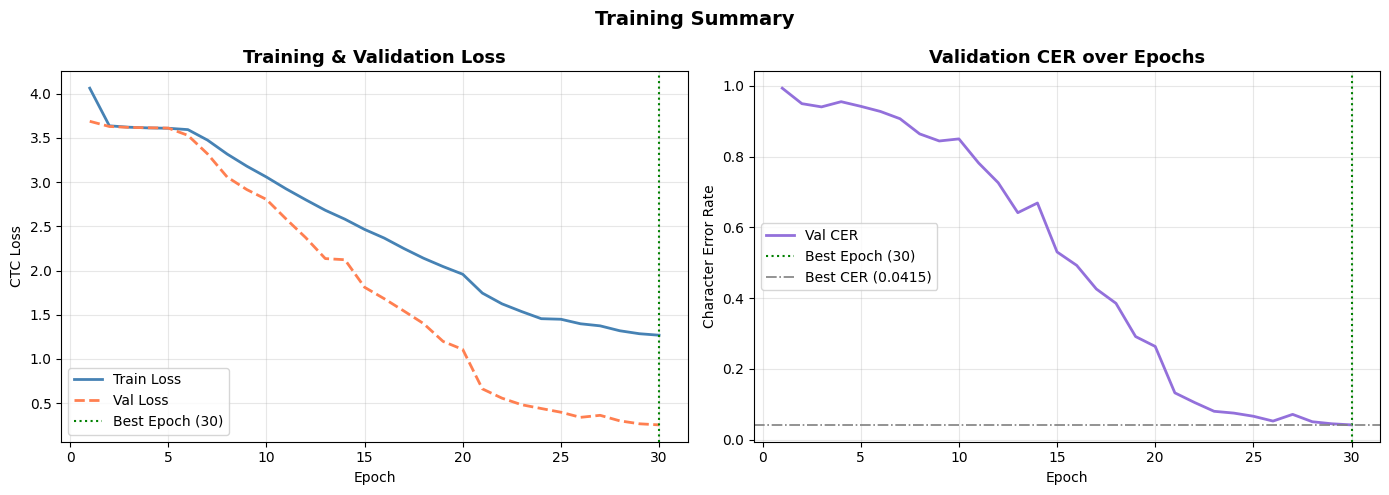


Final Training Summary
  Best Val CER  : 0.0415
  Best Epoch    : 30
  Final LR      : 0.000100


In [35]:
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss Curve ---
axes[0].plot(epochs_range, train_losses, label='Train Loss',
             color='steelblue', linewidth=2)
axes[0].plot(epochs_range, val_losses,   label='Val Loss',
             color='coral', linewidth=2, linestyle='--')
axes[0].axvline(x=best_epoch, color='green', linestyle=':',
                linewidth=1.5, label=f'Best Epoch ({best_epoch})')
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CTC Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- CER Curve ---
axes[1].plot(epochs_range, val_cers, label='Val CER',
             color='mediumpurple', linewidth=2)
axes[1].axvline(x=best_epoch, color='green', linestyle=':',
                linewidth=1.5, label=f'Best Epoch ({best_epoch})')
axes[1].axhline(y=best_val_cer, color='gray', linestyle='-.',
                linewidth=1.2, label=f'Best CER ({best_val_cer:.4f})')
axes[1].set_title('Validation CER over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Character Error Rate')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Training Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal Training Summary")
print(f"  Best Val CER  : {best_val_cer:.4f}")
print(f"  Best Epoch    : {best_epoch}")
print(f"  Final LR      : {optimizer.param_groups[0]['lr']:.6f}")

# Section 13 — Error Analysis

Simply achieving a low CER number is not enough — we must understand *why* and *where* the model fails. This section loads the best checkpoint, runs inference on the validation set, and investigates error patterns.

### 13.1 Load Best Checkpoint and Run Validation Inference

In [36]:
# Load best saved model
load_checkpoint(BEST_CHECKPOINT_PATH, model)

# Run full validation with per-sample results
_, final_cer, val_results = validate(model, val_loader, ctc_loss_fn, DEVICE)

print(f"\nFinal Validation CER (best model) : {final_cer:.4f}")

# Compute per-sample CER
sample_cers = []
for pred, gt in val_results:
    cer = editdistance.eval(pred, gt) / max(len(gt), 1)
    sample_cers.append((pred, gt, cer))

# Sort by CER
sample_cers_sorted = sorted(sample_cers, key=lambda x: x[2])
best_samples  = sample_cers_sorted[:10]       # Lowest CER
worst_samples = sample_cers_sorted[-10:][::-1]  # Highest CER

print(f"\nTotal validation samples : {len(sample_cers)}")
print(f"Perfect predictions (CER=0.0) : {sum(1 for _,_,c in sample_cers if c == 0.0)}")

Checkpoint loaded from: /content/checkpoints/best_model.pth
  Epoch    : 30
  Val CER  : 0.0415



Final Validation CER (best model) : 0.0415

Total validation samples : 3000
Perfect predictions (CER=0.0) : 2330


### 13.2 CER Distribution

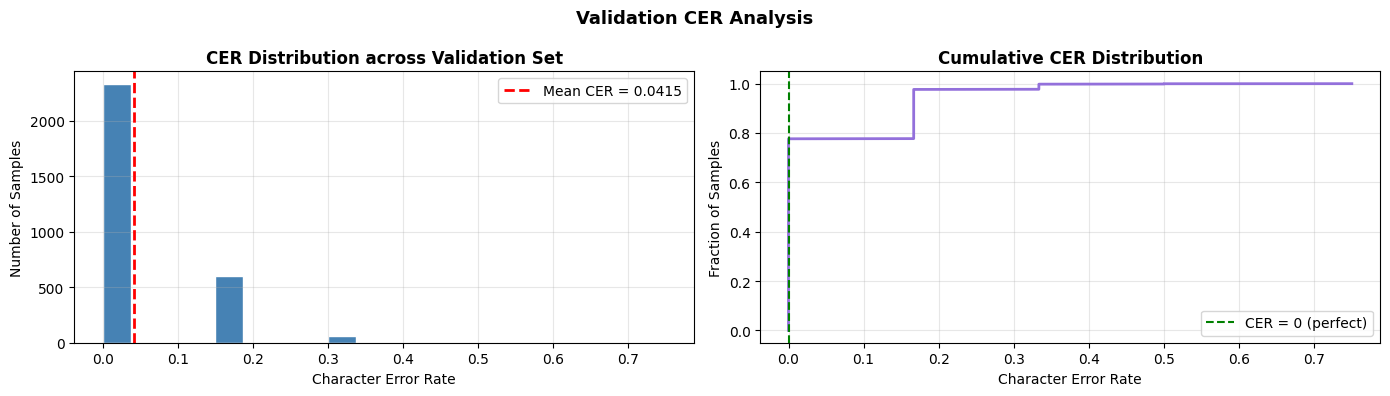

In [37]:
all_cer_values = [c for _, _, c in sample_cers]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram of CER values
axes[0].hist(all_cer_values, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(x=final_cer, color='red', linestyle='--',
                linewidth=2, label=f'Mean CER = {final_cer:.4f}')
axes[0].set_title('CER Distribution across Validation Set',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Character Error Rate')
axes[0].set_ylabel('Number of Samples')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Cumulative CER distribution
sorted_cers = sorted(all_cer_values)
cumulative  = [i / len(sorted_cers) for i in range(len(sorted_cers))]
axes[1].plot(sorted_cers, cumulative, color='mediumpurple', linewidth=2)
axes[1].axvline(x=0.0, color='green', linestyle='--',
                linewidth=1.5, label='CER = 0 (perfect)')
axes[1].set_title('Cumulative CER Distribution',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Character Error Rate')
axes[1].set_ylabel('Fraction of Samples')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Validation CER Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "cer_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()

### 13.3  Best Predictions Showcase

Visualizing the best predictions confirms the model is working correctly and highlights what ideal outcomes look like.

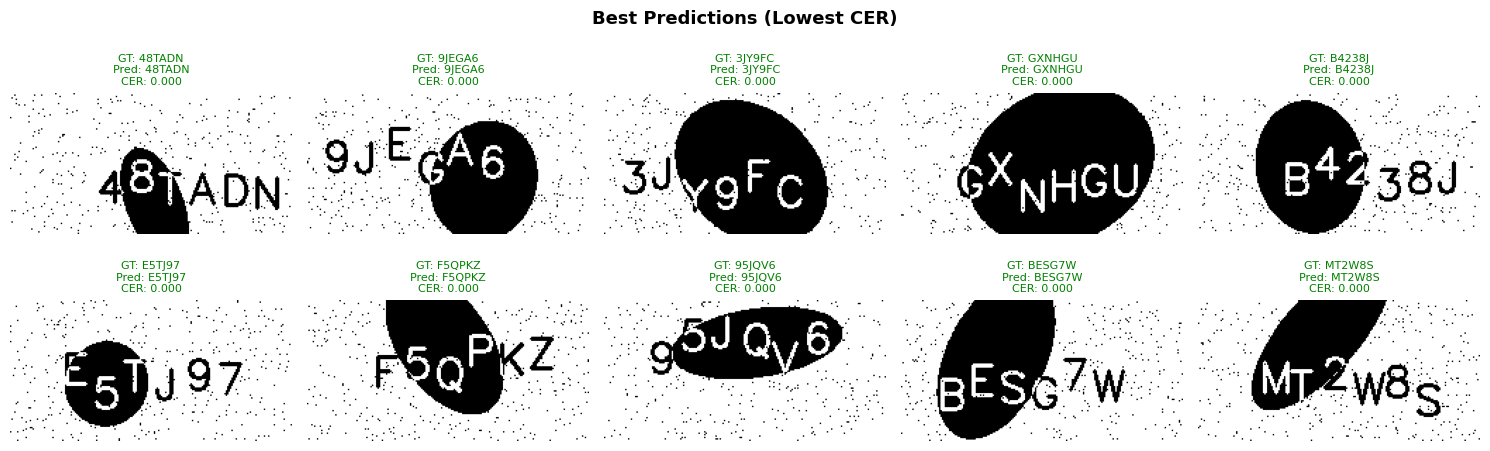

In [38]:
def show_prediction_grid(samples, title, df_source, n_cols=5):
    """
    Displays a grid of images with their predicted and ground truth labels.
    """
    n = len(samples)
    n_rows = math.ceil(n / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5))
    axes = np.array(axes).flatten()

    for i, (pred, gt, cer) in enumerate(samples):
        # Find image path by matching label
        matches = df_source[df_source["label"] == gt]
        if len(matches) > 0:
            img_path = matches.iloc[0]["image_path"]
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                axes[i].imshow(img, cmap="gray")

        color = 'green' if cer == 0.0 else ('orange' if cer < 0.5 else 'red')
        axes[i].set_title(
            f"GT: {gt}\nPred: {pred}\nCER: {cer:.3f}",
            fontsize=8, color=color
        )
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    return fig


fig_best = show_prediction_grid(
    best_samples[:10], "Best Predictions (Lowest CER)", val_df
)
fig_best.savefig(str(OUTPUT_DIR / "best_predictions.png"), dpi=150, bbox_inches='tight')
plt.show()

### 13.4 Worst Predictions Showcase

Examining failure cases is as important as examining successes. These samples reveal the model's current limitations.

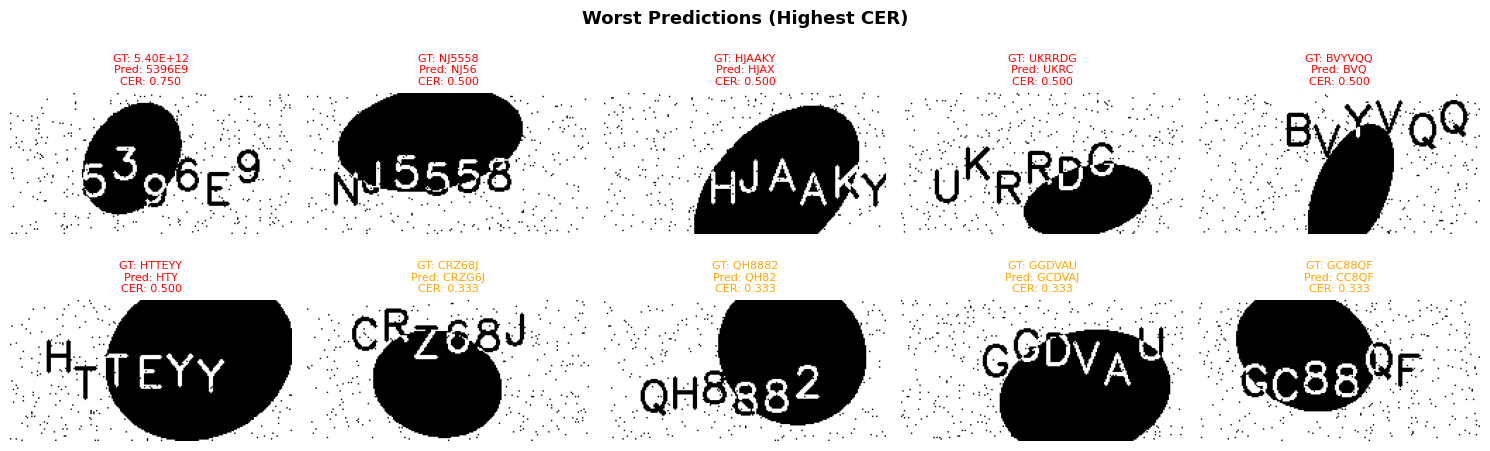

In [39]:
fig_worst = show_prediction_grid(
    worst_samples[:10], "Worst Predictions (Highest CER)", val_df
)
fig_worst.savefig(str(OUTPUT_DIR / "worst_predictions.png"), dpi=150, bbox_inches='tight')
plt.show()

### 13.5 Error Pattern Analysis

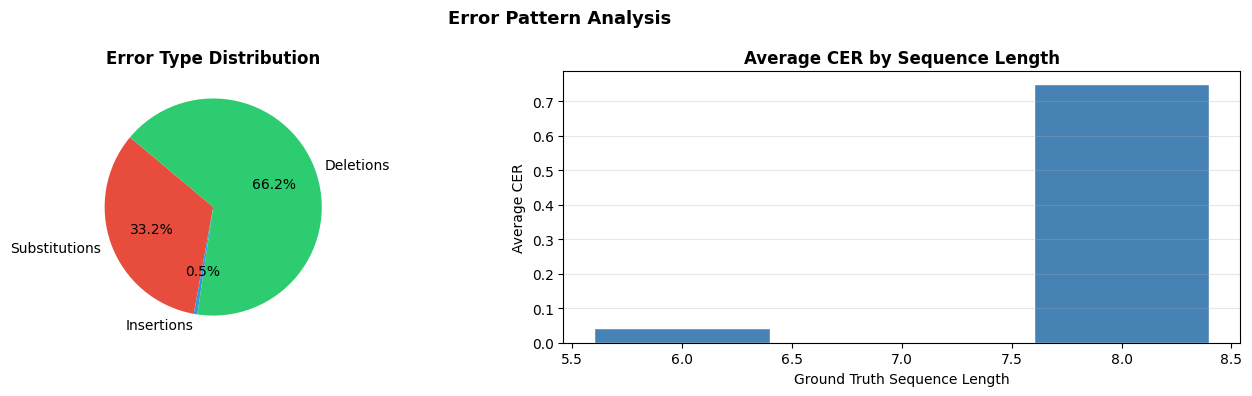

ERROR TYPE BREAKDOWN
  Substitutions : 249
  Insertions    : 4
  Deletions     : 496


In [40]:
# Analyze error types across all validation predictions
substitutions = 0
insertions    = 0
deletions     = 0

length_cer_buckets = {}

for pred, gt, cer in sample_cers:

    # Simple heuristic for error type estimation
    len_diff = len(pred) - len(gt)
    if len_diff > 0:
        insertions += len_diff
    elif len_diff < 0:
        deletions += abs(len_diff)

    # Remaining edit distance approximates substitutions
    edit_d = editdistance.eval(pred, gt)
    substitutions += max(0, edit_d - abs(len_diff))

    # CER by sequence length
    l = len(gt)
    if l not in length_cer_buckets:
        length_cer_buckets[l] = []
    length_cer_buckets[l].append(cer)

# Average CER by sequence length
lengths  = sorted(length_cer_buckets.keys())
avg_cers = [np.mean(length_cer_buckets[l]) for l in lengths]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Error type pie chart
error_labels = ['Substitutions', 'Insertions', 'Deletions']
error_vals   = [substitutions, insertions, deletions]
colors_pie   = ['#e74c3c', '#3498db', '#2ecc71']
axes[0].pie(error_vals, labels=error_labels, colors=colors_pie,
            autopct='%1.1f%%', startangle=140)
axes[0].set_title('Error Type Distribution', fontsize=12, fontweight='bold')

# CER vs sequence length
axes[1].bar(lengths, avg_cers, color='steelblue', edgecolor='white')
axes[1].set_title('Average CER by Sequence Length', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ground Truth Sequence Length')
axes[1].set_ylabel('Average CER')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Error Pattern Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "error_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()

print("ERROR TYPE BREAKDOWN")
print(f"  Substitutions : {substitutions}")
print(f"  Insertions    : {insertions}")
print(f"  Deletions     : {deletions}")

# 14. Generation of Test Predictions and Saving them

In [42]:
# Load best model checkpoint

load_checkpoint(BEST_CHECKPOINT_PATH, model)
model.eval()

predictions = []

with torch.no_grad():
    for images, filenames in tqdm(test_loader, desc="Predicting"):
        images    = images.to(DEVICE)
        log_probs = model(images)
        preds     = greedy_decode_batch(log_probs)

        for fname, pred in zip(filenames, preds):
            predictions.append({"image": fname, "prediction": pred})

print(f"Total predictions generated : {len(predictions)}")
print(f"Sample predictions:")
for p in predictions[:5]:
    print(f"  {p['image']} : {p['prediction']}")

Checkpoint loaded from: /content/checkpoints/best_model.pth
  Epoch    : 30
  Val CER  : 0.0415


Predicting: 100%|██████████| 157/157 [00:06<00:00, 22.73it/s]

Total predictions generated : 5000
Sample predictions:
  test-0.png : QVTQ8A
  test-1.png : 7PSW9D
  test-10.png : 7DUP98
  test-100.png : 75Z4WT
  test-1000.png : QAKZ7V


In [43]:
# Build Submission CSV
df_submission = pd.DataFrame(predictions)

# Verify no missing predictions
assert len(df_submission) == len(df_test), \
    f"Mismatch: {len(df_submission)} predictions for {len(df_test)} test images"
assert df_submission["prediction"].isnull().sum() == 0, \
    "Some predictions are null"

# Save locally in Colab
submission_filename = f"submission_Shah_Daksh_Akhil_24115132.csv"
local_path  = f"/content/{submission_filename}"
drive_path  = f"/content/drive/MyDrive/{submission_filename}"

df_submission.to_csv(local_path, index=False)
df_submission.to_csv(drive_path, index=False)

print(f"Submission saved to Colab  : {local_path}")
print(f"Submission saved to Drive  : {drive_path}")
print(f"\nFirst 5 rows:")
print(df_submission.head())
print(f"\nTotal rows : {len(df_submission)}")

#-------END-------

Submission saved to Colab  : /content/submission_Shah_Daksh_Akhil_24115132.csv
Submission saved to Drive  : /content/drive/MyDrive/submission_Shah_Daksh_Akhil_24115132.csv

First 5 rows:
           image prediction
0     test-0.png     QVTQ8A
1     test-1.png     7PSW9D
2    test-10.png     7DUP98
3   test-100.png     75Z4WT
4  test-1000.png     QAKZ7V

Total rows : 5000
